First, import dependencies.

In [1]:
from bs4 import BeautifulSoup
from cartopy import config
from dotenv import load_dotenv
from sodapy import Socrata

import asyncio
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import os 
import pandas as pd
import requests

Next, load API secrets from `.env` file.

In [2]:
load_dotenv() 

APP_TOKEN = os.environ['SOCRATA_APP_TOKEN']
APP_SECRET = os.environ['SOCRATA_APP_SECRET']

Create the Socrata client.

In [3]:
client = Socrata("data.seattle.gov", APP_TOKEN)

Let's fetch some data!

In [4]:
data = client.get("kzjm-xkqj", limit = 100)

Let's see what fields exist in each row...

In [5]:
data[0]

{'address': '3rd Ave S / S Washington St',
 'type': 'EVENT - Special Event',
 'datetime': '2026-02-11T09:31:00.000',
 'latitude': '47.600877',
 'longitude': '-122.330268',
 'report_location': {'type': 'Point', 'coordinates': [-122.330268, 47.600877]},
 'incident_number': 'F260019787',
 ':@computed_region_ru88_fbhk': '49',
 ':@computed_region_kuhn_3gp2': '22',
 ':@computed_region_q256_3sug': '18379'}

In [6]:
df = pd.DataFrame.from_records(data)
df

,address,type,datetime,latitude,longitude,report_location,incident_number,:@computed_region_ru88_fbhk,:@computed_region_kuhn_3gp2,:@computed_region_q256_3sug,:@computed_region_2day_rhn5,:@computed_region_cyqu_gs94
0,3rd Ave S / S Washington St,EVENT - Special Event,2026-02-11T09:31:00.000,47.600877,-122.330268,"{'type': 'Point', 'coordinates': [-122.330268,...",F260019787,49,22,18379,NaN,NaN
1,589 Occidental Ave S,Aid Response,2026-02-11T09:20:00.000,47.597449,-122.333265,"{'type': 'Point', 'coordinates': [-122.333265,...",F260019786,49,20,18379,NaN,NaN
2,5th Ave S / S Weller St,EVENT - Special Event,2026-02-11T09:19:00.000,47.597517,-122.327675,"{'type': 'Point', 'coordinates': [-122.327675,...",F260019785,27,22,18379,NaN,NaN
3,3028 1st Ave,Aid Response,2026-02-11T09:16:00.000,47.618021,-122.354377,"{'type': 'Point', 'coordinates': [-122.354377,...",F260019784,5,9,18390,NaN,NaN
4,8045 31st Ave Nw,Medic Response,2026-02-11T09:15:00.000,47.687065,-122.397019,"{'type': 'Point', 'coordinates': [-122.397019,...",F260019783,3,23,18798,135,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
95,600 N 130th St,Auto Fire Alarm,2026-02-11T00:49:00.000,47.723223,-122.351624,"{'type': 'Point', 'coordinates': [-122.351624,...",F260019639,6,32,19582,123,1
96,3925 Sw Dawson St,Aid Response,2026-02-11T00:35:00.000,47.555634,-122.381856,"{'type': 'Point', 'coordinates': [-122.381856,...",F260019637,1,50,17916,NaN,NaN
97,9009 Greenwood Ave N,Hang-Up- Aid,2026-02-11T00:34:00.000,47.69429,-122.35534,"{'type': 'Point', 'coordinates': [-122.35534, ...",F260019636,23,21,18377,NaN,NaN
98,1018 S Henderson St,Aid Response,2026-02-11T00:29:00.000,47.523057,-122.320093,"{'type': 'Point', 'coordinates': [-122.320093,...",F260019635,59,15,18388,NaN,NaN


Can we iterate over the rows and plot the points on a map?

In [7]:
float(df["latitude"].min())

47.29567

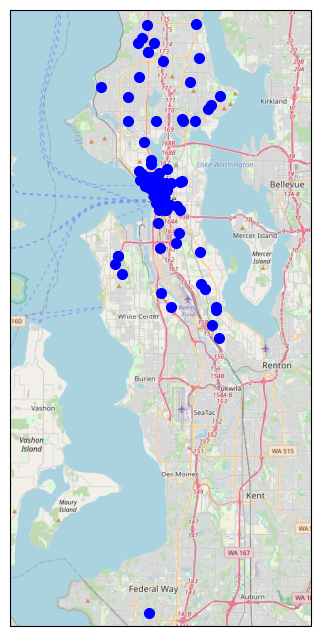

In [8]:
padding = 0.01
lon_min, lon_max = float(df["longitude"].min()) + padding * 10, float(df["longitude"].max()) - padding * 10
lat_min, lat_max = float(df["latitude"].min()) - padding, float(df["latitude"].max()) + padding

osm_tiles = cimgt.OSM()
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': osm_tiles.crs})
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.add_image(osm_tiles, 11)

for datum in data:
    ax.plot(
        float(datum['longitude']), 
        float(datum['latitude']), 
        'bo', markersize=7, transform=ccrs.Geodetic()
    )

plt.show()

Neat! Now, SFD live (sfdlive.com) has "richer" data than we have. They actually know which units were assigned to which event. Would it be possible for us to create a map of events that a specific unit responds to? And perhaps plot the route most likely taken between each event? To get an estimated sense of how far each unit drives every hour? That would be an interesting question to ask of the available data and one that could perhaps be useful for shift scheduling?

I found a website that queries the unit dispatch data via `https://web.seattle.gov/sfd/IncidentSearch/incidentDetail.asp?ID=F260019374`. The resulting web page shows unit assignments. Can I do this with Python using the `requests` library?

In [89]:
incident_id = "F260019859"
incident_id

'F260019859'

In [90]:
def make_incident_url_from_id(incident_id):
    sfd_url_template = "https://web.seattle.gov/sfd/IncidentSearch/incidentDetail.asp?ID={}"
    incident_url = sfd_url_template.format(incident_id)
    return incident_url

incident_url = make_incident_url_from_id(incident_id)
incident_url

'https://web.seattle.gov/sfd/IncidentSearch/incidentDetail.asp?ID=F260019859'

In [91]:
response = requests.get(incident_url)
response

<Response [200]>

We'll use BeautifulSoup to parse the HTML contents in the response.

In [92]:
soup = BeautifulSoup(response.content, 'html.parser')

I need to extract the `table` elements.

In [98]:
def get_unit_dispatches_from_incident_id(incident_id):
    incident_url = make_incident_url_from_id(incident_id)
    response = requests.get(incident_url)
    if response.status_code != 200:
        raise RuntimeError
    soup = BeautifulSoup(response.content, 'html.parser')
    top_level_table = soup.find("table")
    middle_tables = top_level_table.find_all("table")
    if len(middle_tables) <= 1:
        return "error"
    bottom_table = middle_tables[1].find("table")
    table_rows = bottom_table.find_all("tr")[1:]
    return_list = []
    for row in table_rows:
        entries = row.find_all("p")
        unit = entries[0].text.strip()
        dispatched = entries[1].text.strip()
        arrived = entries[2].text.strip()
        in_service = entries[3].text.strip()
        return_list.append(
            {
                "unit": unit,
                "dispatched": dispatched,
                "arrived": arrived,
                "in_service": in_service
            }
        )
    return return_list

In [99]:
get_unit_dispatches_from_incident_id("F260019791")

[{'unit': 'E30',
  'dispatched': '09:41',
  'arrived': '09:46',
  'in_service': '10:17'},
 {'unit': 'E6*',
  'dispatched': '09:40',
  'arrived': '09:44',
  'in_service': '10:42'},
 {'unit': 'M28',
  'dispatched': '09:41',
  'arrived': '09:44',
  'in_service': '10:30'}]

In [100]:
get_unit_dispatches_from_incident_id("F2600197912")

'error'

Great! We've accessed incident-level unit dispatch data! What are some useful insights we can hope to gain from this information? What are some interesting questions to ask?<br><br>How long does each unit spend en-route to all their incidents? Average per incident?<br>How long does each unit spend active on-site to all their incidents? Average per incident?<br>How many incidents does each unit respond to?